In [1]:
import pandas as pd

In [2]:
def show_average_scores(csv_path='audio_quality_evaluation.csv'):
    """
    读取 CSV 文件并显示各列的平均值
    """
    # 读取 CSV
    df = pd.read_csv(csv_path)
    
    # 获取数值列（排除 file_name 和 category）
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    # 计算平均值
    avg_scores = df[numeric_cols].mean()
    
    # 打印结果
    print("各列平均值：")
    print("=" * 50)
    for col, avg in avg_scores.items():
        print(f"{col:20s}: {avg:.4f}")
    
    return avg_scores

In [ ]:
avg_scores = show_average_scores()

各列平均值：
raw_ovrl            : 2.5606
raw_sig             : 3.0479
raw_bak             : 3.6024
frcrn_se_ovrl       : 2.6827
frcrn_se_sig        : 3.1130
frcrn_se_bak        : 3.8800
demucs_ovrl         : 2.7063
demucs_sig          : 3.1496
demucs_bak          : 3.9118


In [4]:
from spectrogram import show_mel_spectrograms, show_difference_mel_spectrograms, show_waveform_comparison, show_log_mel_spectrograms, show_difference_log_mel_spectrograms

In [5]:
AUDIO_ID = '002-0.wav'
CATEGORY = 'Control'

## Mel Spectrogram

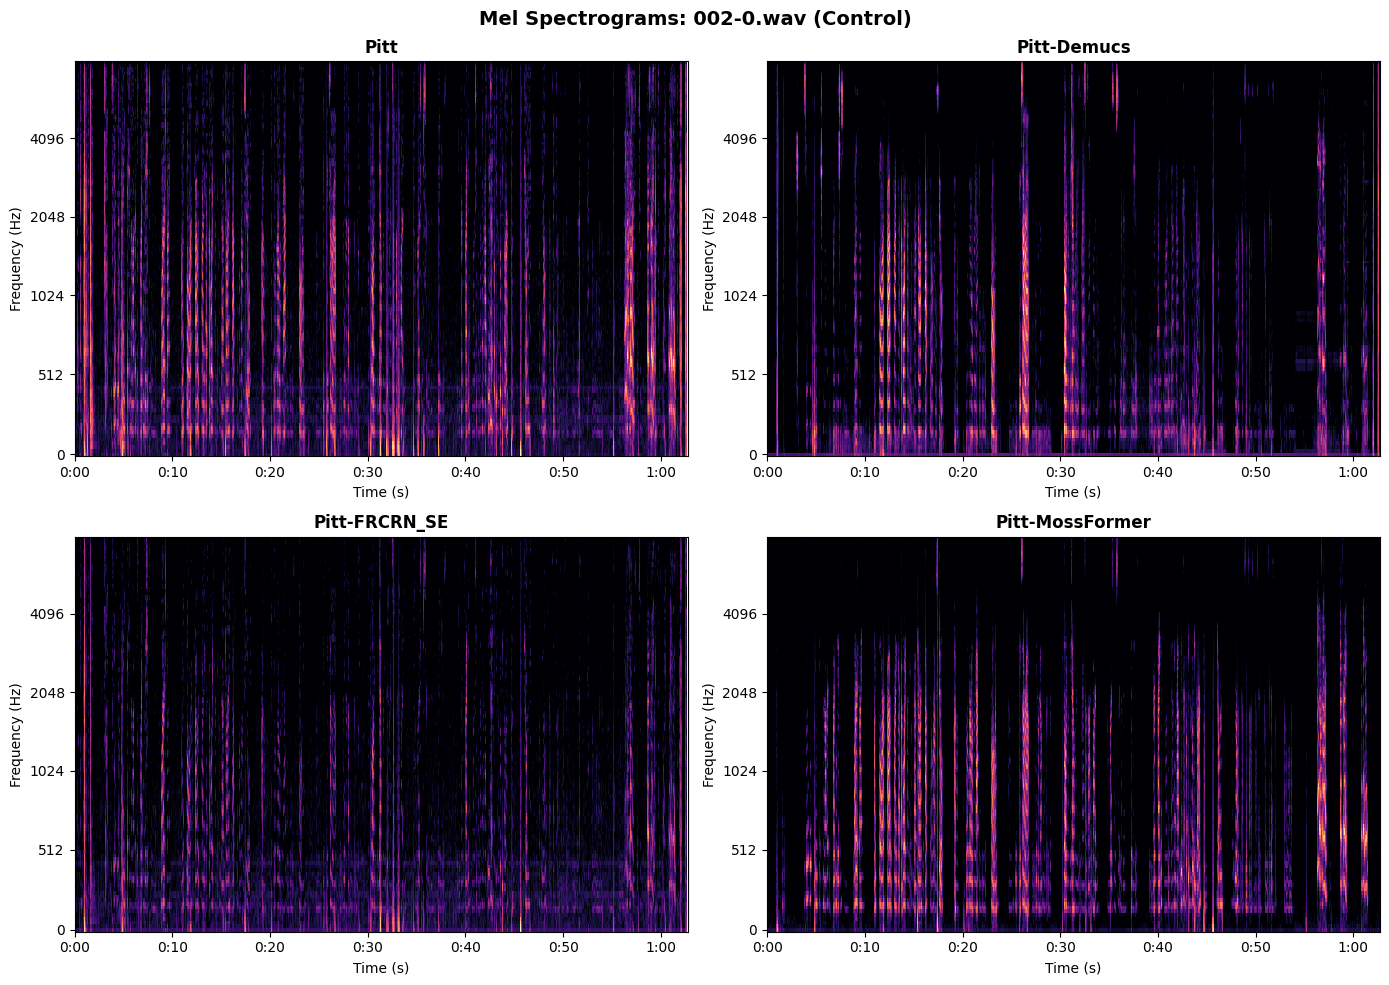

In [6]:
show_mel_spectrograms(AUDIO_ID, CATEGORY)

## Log-Mel Spectrogram

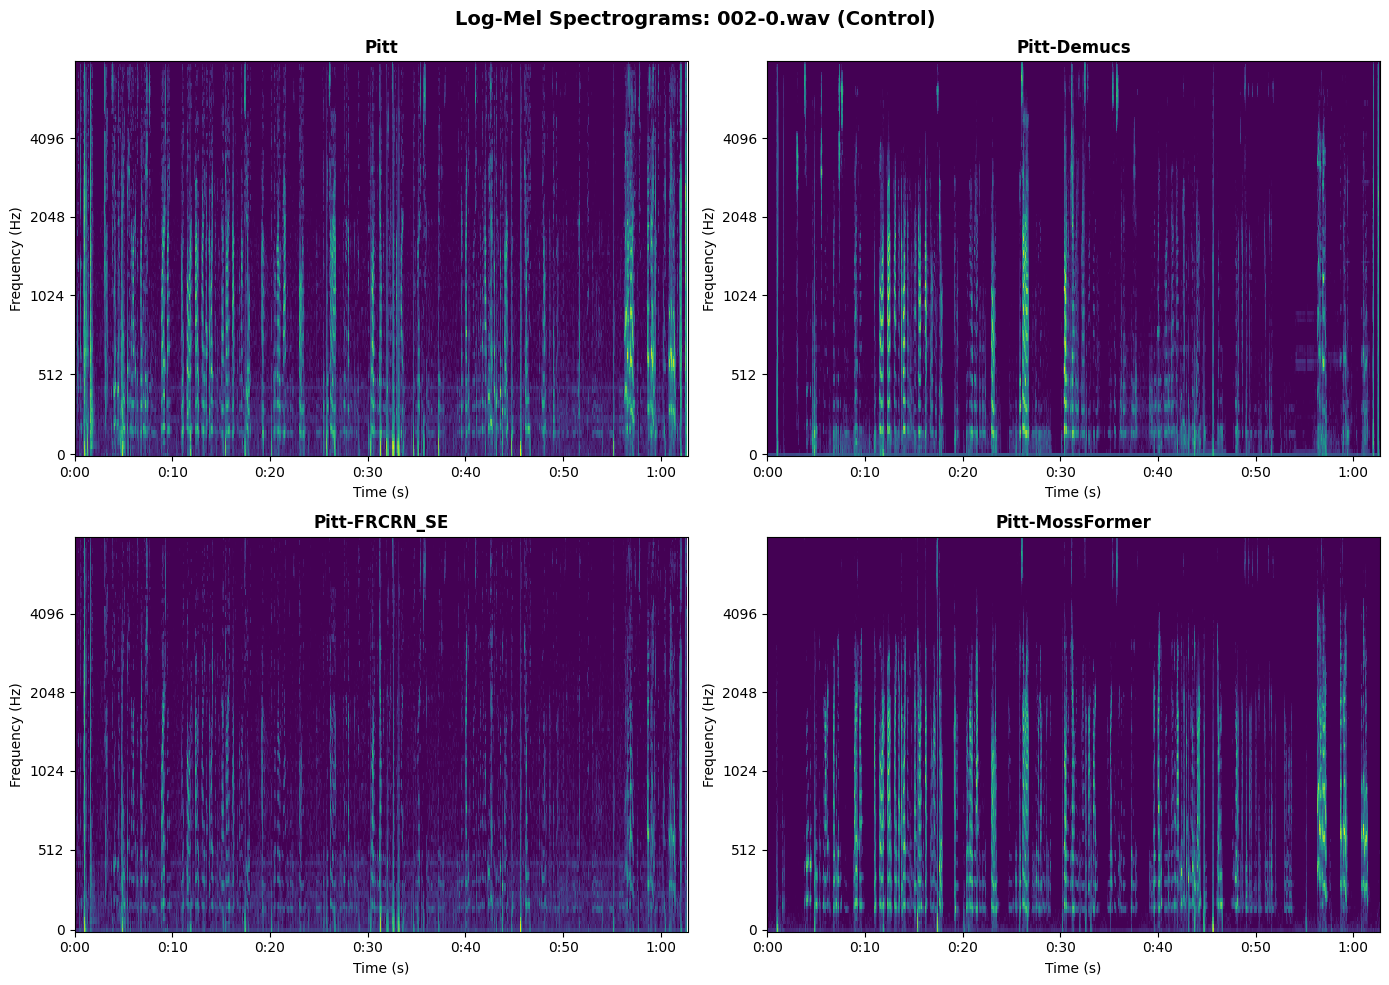

In [7]:
show_log_mel_spectrograms(AUDIO_ID, CATEGORY)

## Waveform

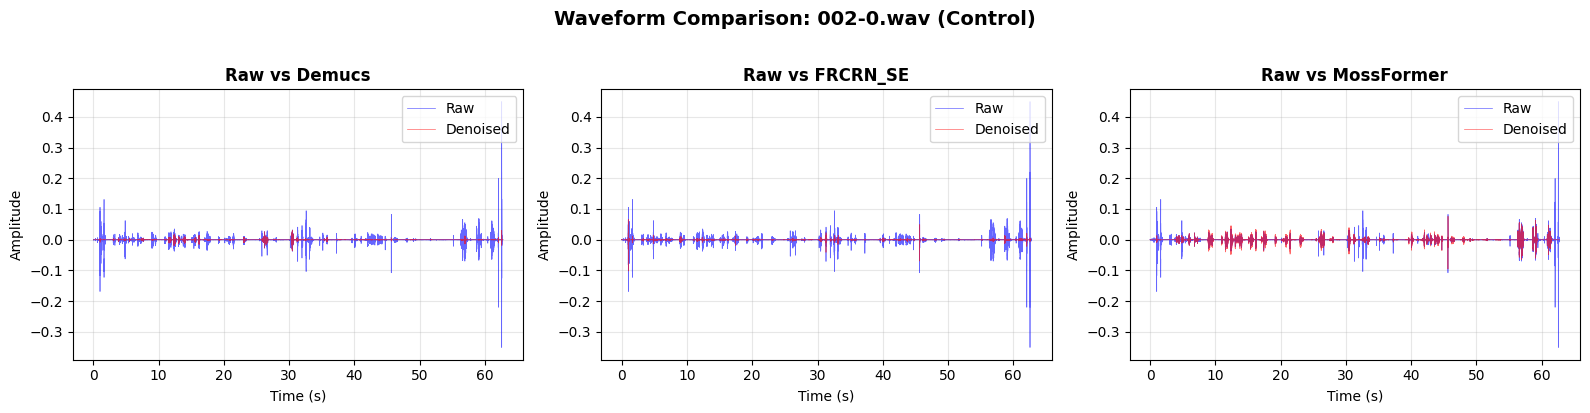

In [8]:

show_waveform_comparison(AUDIO_ID, CATEGORY)

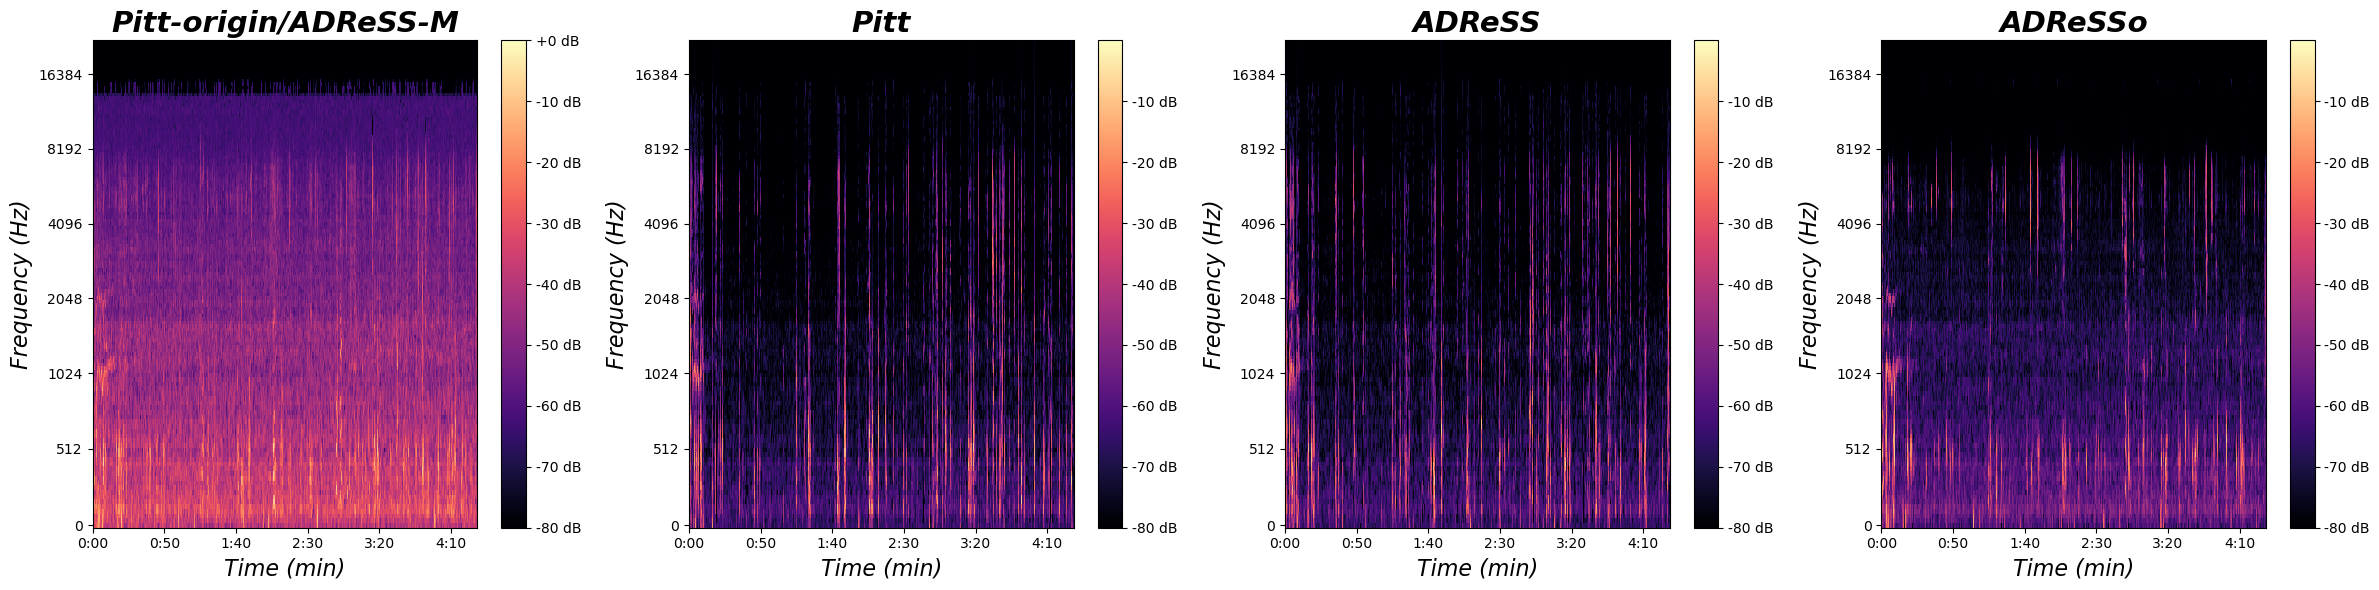

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 五个数据集中最长时长的 Dementia 音频文件（~268s）
audio_files = {
    'Pitt-origin/ADReSS-M': '../ad_detection/data/raw/Pitt-origin/Dementia/268-0.mp3',
    'Pitt': '../ad_detection/data/raw/Pitt/Dementia/268-0.wav',
    'ADReSS': '../ad_detection/data/raw/ADReSS/Dementia/S167.wav',
    'ADReSSo': '../ad_detection/data/raw/ADReSSo/Dementia/adrso056.wav',
    # 'ADReSS-M': '../ad_detection/data/raw/ADReSS-M/Dementia/adrso056.mp3',
}

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes_flat = axes.flatten()

for idx, (name, path) in enumerate(audio_files.items()):
    y, sr = librosa.load(path, sr=None)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    ax = axes_flat[idx]
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'{name}', fontsize=21, fontweight='bold', fontstyle='italic')
    ax.set_xlabel('Time (min)', fontsize=16, fontstyle='italic')
    ax.set_ylabel('Frequency (Hz)', fontsize=16, fontstyle='italic')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.savefig('mel_spectrogram_dementia_comparison.pdf', bbox_inches='tight')
plt.show()